# 🚗 Tesla Deliveries & Production — End-to-End ML Pipeline
**Dataset:** Tesla EA Deliveries & Production Data (2015–2025)

### Topics Covered
1. Data Preprocessing  
2. Exploratory Data Analysis (EDA)  
3. Feature Engineering  
4. Regression Modeling  
5. Hyperparameter Tuning  
6. Time Series Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')
print("Shape:", df.shape)
df.head()

Shape: (2640, 12)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


---
## 1. Data Preprocessing

In [2]:
print("Data Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
df.describe().round(2)

Data Types:
Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

Missing Values:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows: 0


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00,2640.00
mean,2020.00,6.50,9922.20,10655.85,84907.34,87.06,500.26,744.08,8932.13
std,3.16,3.45,3935.95,4260.60,20123.26,20.84,120.87,353.22,3469.57
min,2015.00,1.00,48.00,50.00,50003.70,60.00,330.00,3.07,3002.00
25%,2017.00,3.75,7292.00,7828.25,67726.36,75.00,418.00,499.62,5897.75
50%,2020.00,6.50,9857.00,10546.50,85058.51,82.00,470.00,699.52,8901.50
75%,2023.00,9.25,12510.25,13469.00,102373.04,100.00,586.25,943.76,11938.00
max,2025.00,12.00,25704.00,28939.00,119965.36,120.00,719.00,2548.55,14996.00


In [3]:
df = df.drop_duplicates().reset_index(drop=True)

le_region = LabelEncoder()
le_model  = LabelEncoder()
le_source = LabelEncoder()

df['Region_enc'] = le_region.fit_transform(df['Region'])
df['Model_enc']  = le_model.fit_transform(df['Model'])
df['Source_enc'] = le_source.fit_transform(df['Source_Type'])

print("Regions:", le_region.classes_)
print("Models :", le_model.classes_)
print("Sources:", le_source.classes_)

Regions: ['Asia' 'Europe' 'Middle East' 'North America']
Models : ['Cybertruck' 'Model 3' 'Model S' 'Model X' 'Model Y']
Sources: ['Estimated (Region)' 'Interpolated (Month)' 'Official (Quarter)']


---
## 2. Exploratory Data Analysis (EDA)

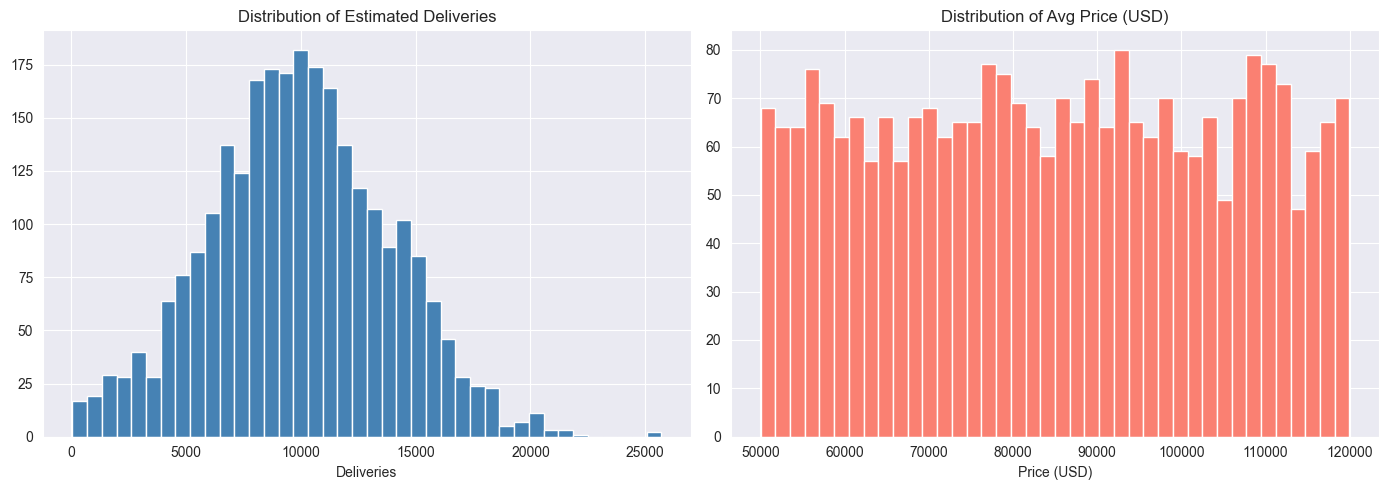

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Estimated_Deliveries'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Estimated Deliveries')
axes[0].set_xlabel('Deliveries')

axes[1].hist(df['Avg_Price_USD'], bins=40, color='salmon', edgecolor='white')
axes[1].set_title('Distribution of Avg Price (USD)')
axes[1].set_xlabel('Price (USD)')
plt.tight_layout(); plt.show()

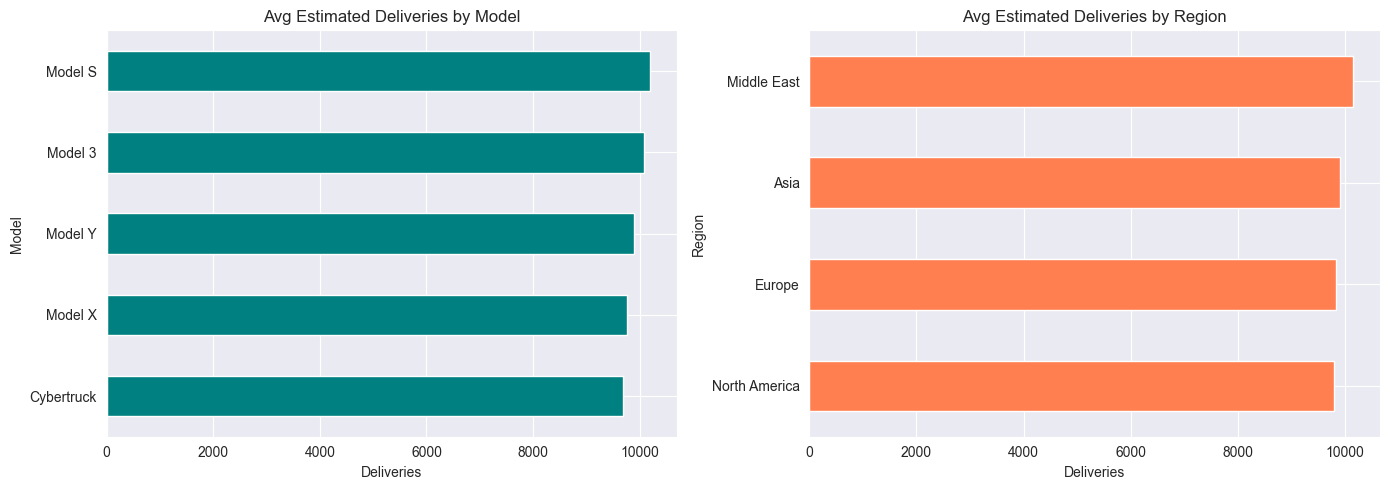

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.groupby('Model')['Estimated_Deliveries'].mean().sort_values().plot(
    kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Avg Estimated Deliveries by Model')
axes[0].set_xlabel('Deliveries')

df.groupby('Region')['Estimated_Deliveries'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Avg Estimated Deliveries by Region')
axes[1].set_xlabel('Deliveries')
plt.tight_layout(); plt.show()

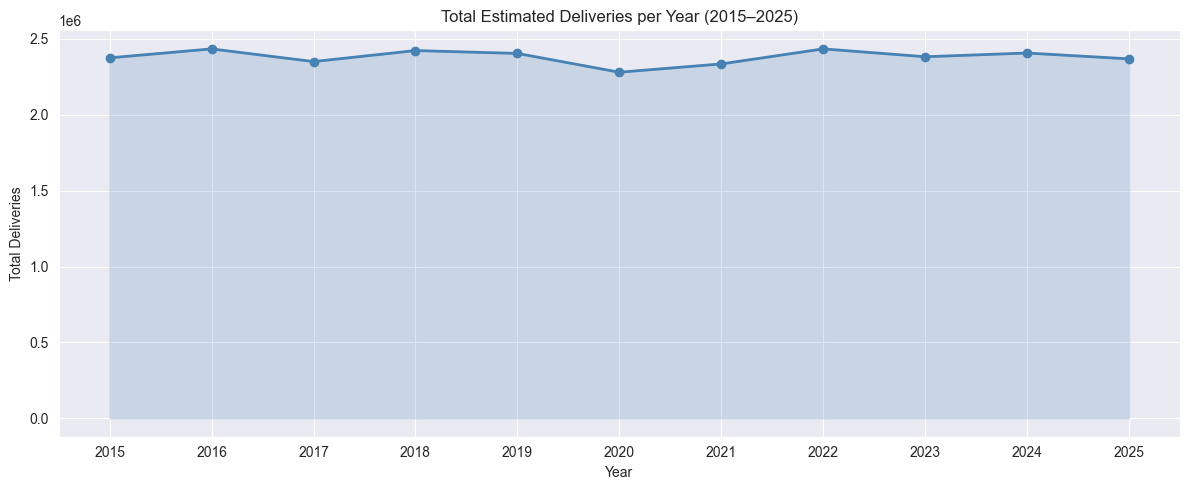

In [6]:
yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
plt.figure(figsize=(12, 5))
plt.plot(yearly['Year'], yearly['Estimated_Deliveries'], marker='o',
         color='steelblue', linewidth=2)
plt.fill_between(yearly['Year'], yearly['Estimated_Deliveries'], alpha=0.2, color='steelblue')
plt.title('Total Estimated Deliveries per Year (2015–2025)')
plt.xlabel('Year'); plt.ylabel('Total Deliveries')
plt.xticks(yearly['Year'].astype(int))
plt.tight_layout(); plt.show()

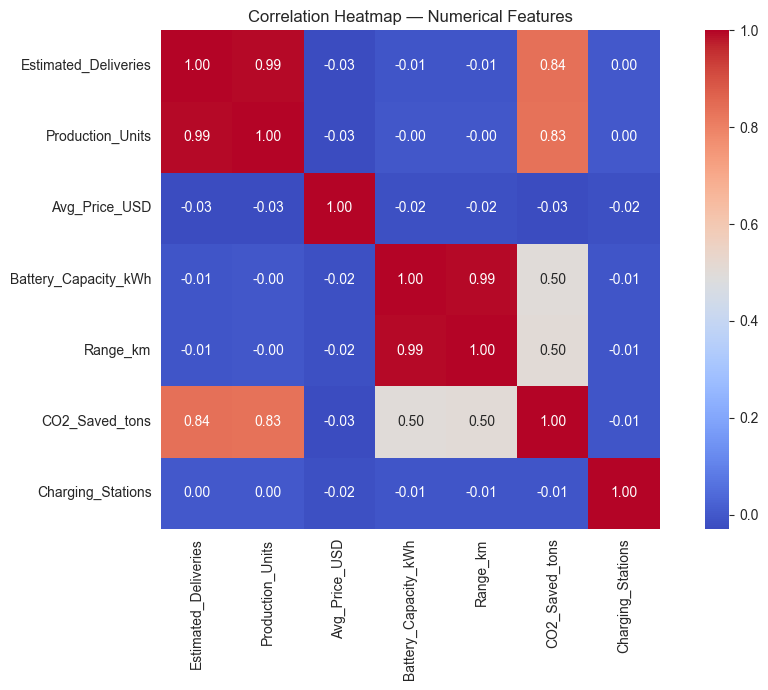

In [7]:
num_cols = ['Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD',
            'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations']
plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout(); plt.show()

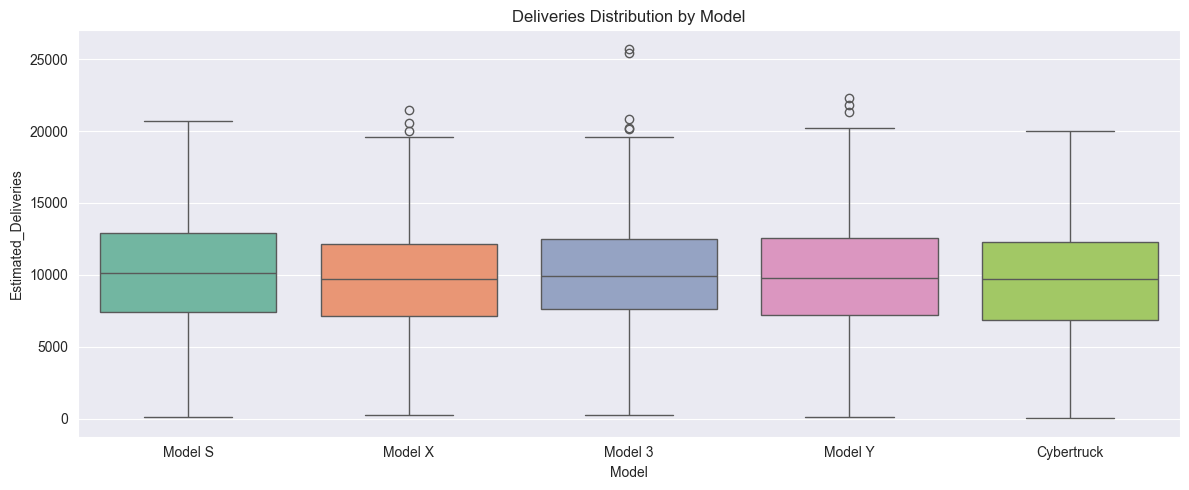

In [8]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='Model', y='Estimated_Deliveries', palette='Set2')
plt.title('Deliveries Distribution by Model')
plt.tight_layout(); plt.show()

---
## 3. Feature Engineering

In [9]:
df['Delivery_Rate']        = df['Estimated_Deliveries'] / (df['Production_Units'] + 1)
df['CO2_per_Delivery']     = df['CO2_Saved_tons'] / (df['Estimated_Deliveries'] + 1)
df['Price_per_Range']      = df['Avg_Price_USD'] / (df['Range_km'] + 1)
df['Station_per_Delivery'] = df['Charging_Stations'] / (df['Estimated_Deliveries'] + 1)
df['Quarter']              = ((df['Month'] - 1) // 3) + 1

def get_season(m):
    if m in [12, 1, 2]: return 0   # Winter
    elif m in [3, 4, 5]: return 1  # Spring
    elif m in [6, 7, 8]: return 2  # Summer
    else: return 3                 # Fall

df['Season_enc'] = df['Month'].apply(get_season)

print("New engineered features:")
print(df[['Delivery_Rate','CO2_per_Delivery','Price_per_Range','Quarter','Season_enc']].head(5))

New engineered features:
   Delivery_Rate  CO2_per_Delivery  Price_per_Range  Quarter  Season_enc
0       0.984545          0.105594       131.736553        2           1
1       0.911645          0.065682       141.698519        1           0
2       0.915234          0.071991       245.087983        1           0
3       0.896472          0.106783       125.238303        1           0
4       0.914020          0.099142       173.484562        4           0


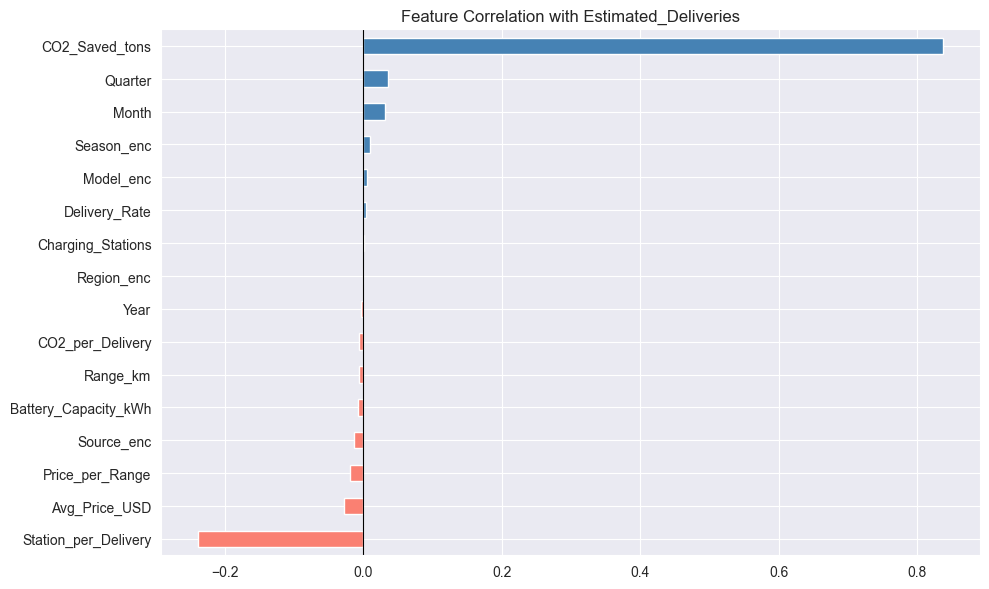

In [10]:
feature_cols = ['Avg_Price_USD','Battery_Capacity_kWh','Range_km','CO2_Saved_tons',
                'Charging_Stations','Delivery_Rate','CO2_per_Delivery',
                'Price_per_Range','Station_per_Delivery','Region_enc','Model_enc',
                'Year','Month','Quarter','Season_enc','Source_enc']

corr_target = (df[feature_cols + ['Estimated_Deliveries']]
               .corr()['Estimated_Deliveries']
               .drop('Estimated_Deliveries')
               .sort_values())

plt.figure(figsize=(10, 6))
colors = ['salmon' if v < 0 else 'steelblue' for v in corr_target.values]
corr_target.plot(kind='barh', color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Estimated_Deliveries')
plt.tight_layout(); plt.show()

---
## 4. Regression Modeling

In [11]:
X = df[feature_cols].copy()
y = df['Estimated_Deliveries'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

Train size: (2112, 16), Test size: (528, 16)


In [12]:
def evaluate(name, model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    pred  = model.predict(Xte)
    rmse  = np.sqrt(mean_squared_error(yte, pred))
    mae   = mean_absolute_error(yte, pred)
    r2    = r2_score(yte, pred)
    print(f"{name:35s}  RMSE={rmse:8.1f}  MAE={mae:8.1f}  R²={r2:.4f}")
    return dict(Model=name, RMSE=rmse, MAE=mae, R2=r2, pred=pred)

print(f"{'Model':35s}  {'RMSE':>10}  {'MAE':>10}  {'R²':>8}")
print("-" * 70)
results = [
    evaluate("Linear Regression",    LinearRegression(),                               X_train_sc, X_test_sc, y_train, y_test),
    evaluate("Ridge (α=1)",          Ridge(alpha=1.0),                                 X_train_sc, X_test_sc, y_train, y_test),
    evaluate("Lasso (α=1)",          Lasso(alpha=1.0),                                 X_train_sc, X_test_sc, y_train, y_test),
    evaluate("Random Forest",        RandomForestRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test),
    evaluate("Gradient Boosting",    GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, X_test, y_train, y_test),
]

Model                                      RMSE         MAE        R²
----------------------------------------------------------------------
Linear Regression                    RMSE=   910.9  MAE=   648.8  R²=0.9443
Ridge (α=1)                          RMSE=   925.9  MAE=   656.7  R²=0.9425
Lasso (α=1)                          RMSE=   926.2  MAE=   656.6  R²=0.9424


Random Forest                        RMSE=   167.7  MAE=   116.8  R²=0.9981


Gradient Boosting                    RMSE=   236.4  MAE=   185.0  R²=0.9963


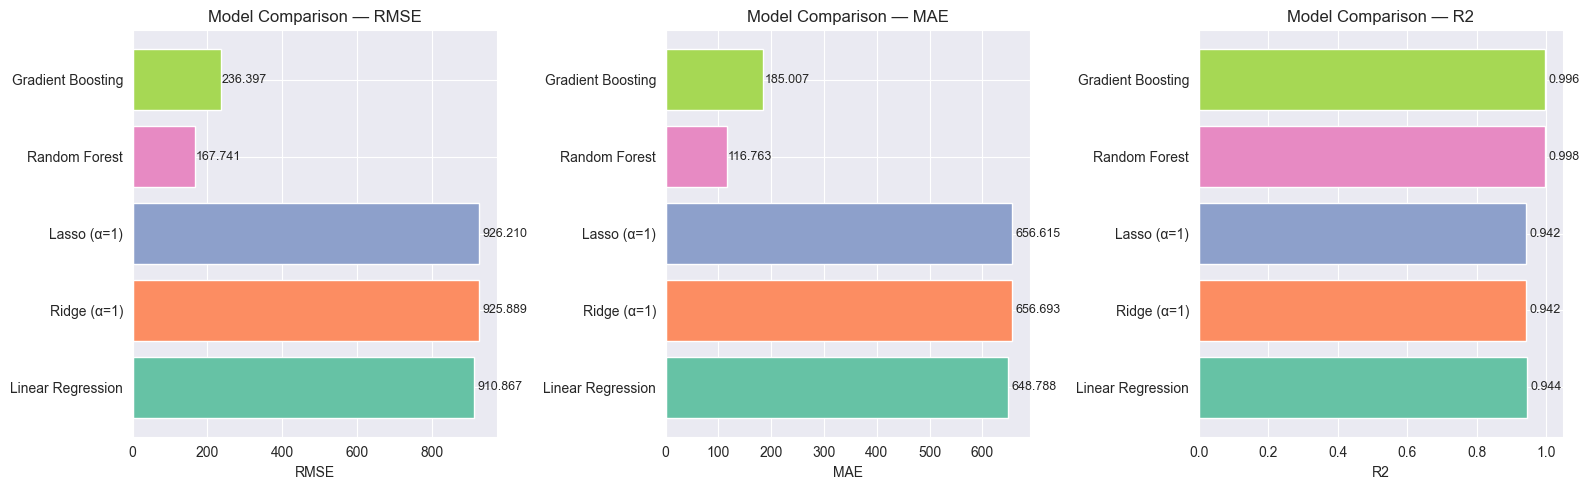

In [13]:
res_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'pred'} for r in results])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, ['RMSE', 'MAE', 'R2']):
    bars = ax.barh(res_df['Model'], res_df[metric],
                   color=sns.color_palette('Set2', len(res_df)))
    ax.set_title(f'Model Comparison — {metric}')
    ax.set_xlabel(metric)
    for bar in bars:
        w = bar.get_width()
        ax.text(w * 1.01, bar.get_y() + bar.get_height() / 2,
                f'{w:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

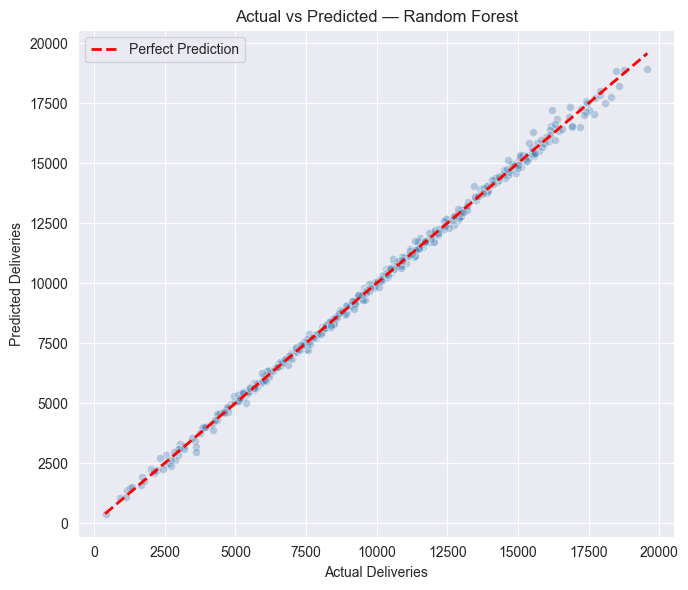

In [14]:
rf_preds = results[3]['pred']
plt.figure(figsize=(7, 6))
plt.scatter(y_test, rf_preds, alpha=0.35, color='steelblue', edgecolor='white')
lims = [min(y_test.min(), rf_preds.min()), max(y_test.max(), rf_preds.max())]
plt.plot(lims, lims, 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Deliveries'); plt.ylabel('Predicted Deliveries')
plt.title('Actual vs Predicted — Random Forest')
plt.legend(); plt.tight_layout(); plt.show()

5-Fold CV R² Scores: [0.9951 0.9951 0.9929 0.9975 0.9976]
Mean R²: 0.9956  ±  Std: 0.0017


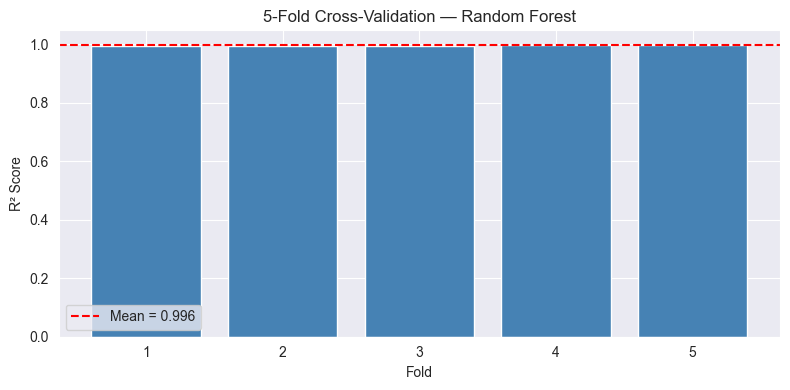

In [15]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print("5-Fold CV R² Scores:", cv_scores.round(4))
print(f"Mean R²: {cv_scores.mean():.4f}  ±  Std: {cv_scores.std():.4f}")

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold'); plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation — Random Forest')
plt.legend(); plt.tight_layout(); plt.show()

---
## 5. Hyperparameter Tuning (GridSearchCV)

In [16]:
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best CV R² :", round(grid_search.best_score_, 4))

Fitting 3 folds for each of 18 candidates, totalling 54 fits


Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R² : 0.9934


Tuned Random Forest — Test Set
  RMSE : 168.21
  MAE  : 116.20
  R²   : 0.9981


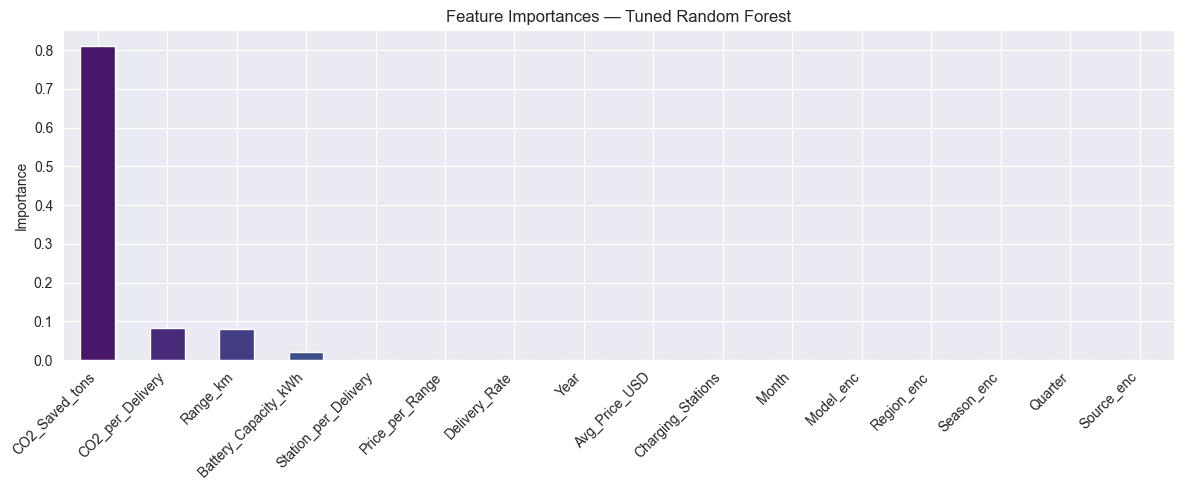

In [17]:
best_rf   = grid_search.best_estimator_
tuned_pred = best_rf.predict(X_test)

print("Tuned Random Forest — Test Set")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_test, tuned_pred)):.2f}")
print(f"  MAE  : {mean_absolute_error(y_test, tuned_pred):.2f}")
print(f"  R²   : {r2_score(y_test, tuned_pred):.4f}")

importances = (pd.Series(best_rf.feature_importances_, index=feature_cols)
               .sort_values(ascending=False))
plt.figure(figsize=(12, 5))
importances.plot(kind='bar', color=sns.color_palette('viridis', len(importances)))
plt.title('Feature Importances — Tuned Random Forest')
plt.ylabel('Importance'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

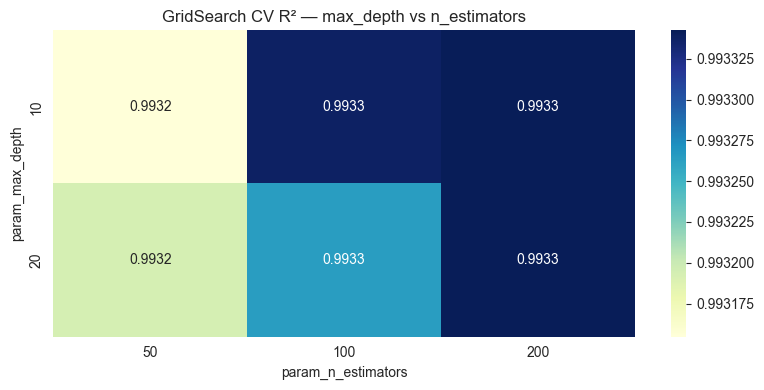

In [18]:
gs_df  = pd.DataFrame(grid_search.cv_results_)
pivot  = gs_df.pivot_table(
    values='mean_test_score',
    index='param_max_depth',
    columns='param_n_estimators',
    aggfunc='mean')

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGnBu')
plt.title('GridSearch CV R² — max_depth vs n_estimators')
plt.tight_layout(); plt.show()

---
## 6. Time Series Forecasting

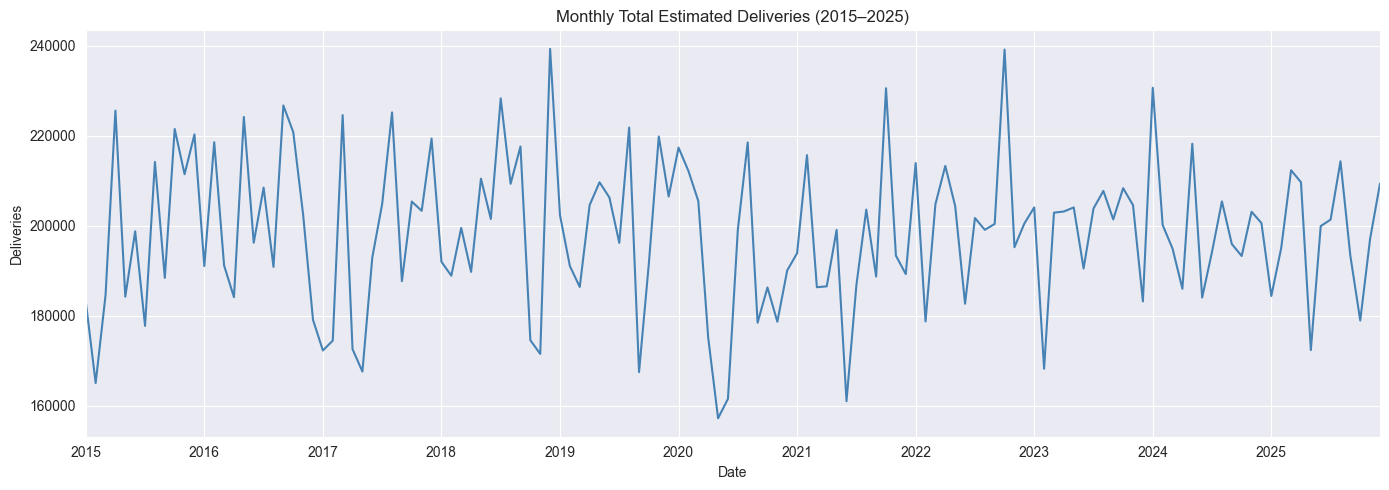

Series length: 132 months


In [19]:
ts_df = (df.groupby(['Year', 'Month'])['Estimated_Deliveries']
           .sum()
           .reset_index()
           .sort_values(['Year', 'Month']))
ts_df['Date'] = pd.to_datetime(ts_df[['Year','Month']].assign(Day=1))
ts = ts_df.set_index('Date')['Estimated_Deliveries']

plt.figure(figsize=(14, 5))
ts.plot(color='steelblue', linewidth=1.5)
plt.title('Monthly Total Estimated Deliveries (2015–2025)')
plt.xlabel('Date'); plt.ylabel('Deliveries')
plt.tight_layout(); plt.show()
print("Series length:", len(ts), "months")

/opt/homebrew/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


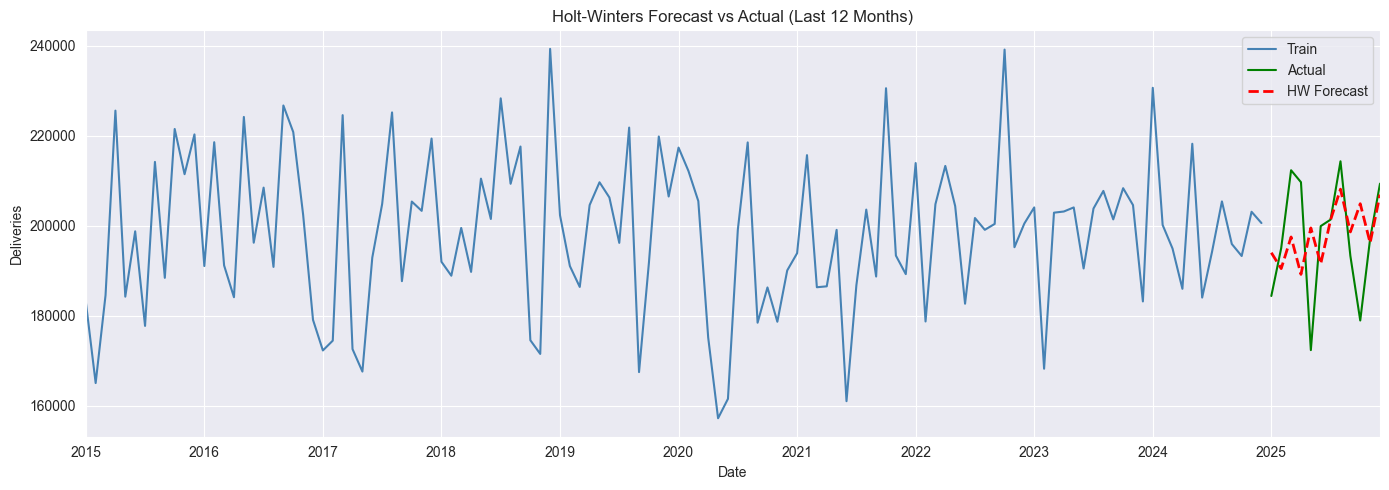

Holt-Winters  RMSE=13871.2  MAE=10494.8


In [20]:
train_ts = ts[:-12]
test_ts  = ts[-12:]

hw_model    = ExponentialSmoothing(train_ts, trend='add',
                                    seasonal='add', seasonal_periods=12).fit()
hw_forecast = hw_model.forecast(12)
hw_forecast.index = test_ts.index

plt.figure(figsize=(14, 5))
train_ts.plot(label='Train', color='steelblue', linewidth=1.5)
test_ts.plot(label='Actual', color='green', linewidth=1.5)
hw_forecast.plot(label='HW Forecast', color='red', linestyle='--', linewidth=2)
plt.title('Holt-Winters Forecast vs Actual (Last 12 Months)')
plt.xlabel('Date'); plt.ylabel('Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

print(f"Holt-Winters  RMSE={np.sqrt(mean_squared_error(test_ts, hw_forecast)):.1f}  "
      f"MAE={mean_absolute_error(test_ts, hw_forecast):.1f}")

/opt/homebrew/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/homebrew/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


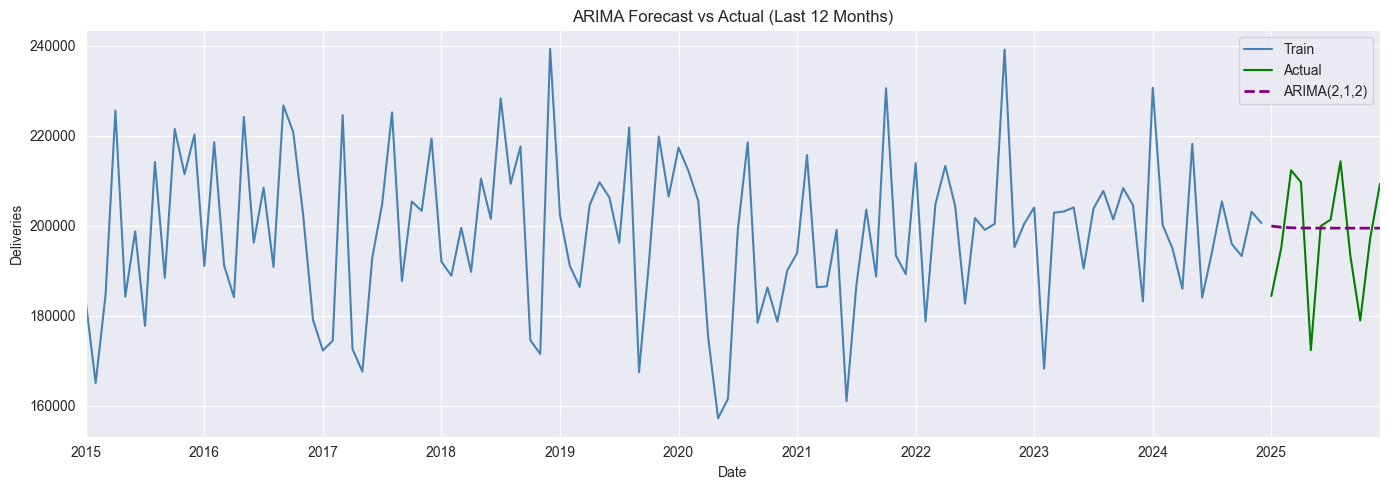

ARIMA(2,1,2)  RMSE=13085.4  MAE=10535.6


In [21]:
arima_model    = ARIMA(train_ts, order=(2, 1, 2)).fit()
arima_forecast = arima_model.forecast(steps=12)
arima_forecast.index = test_ts.index

plt.figure(figsize=(14, 5))
train_ts.plot(label='Train', color='steelblue', linewidth=1.5)
test_ts.plot(label='Actual', color='green', linewidth=1.5)
arima_forecast.plot(label='ARIMA(2,1,2)', color='purple', linestyle='--', linewidth=2)
plt.title('ARIMA Forecast vs Actual (Last 12 Months)')
plt.xlabel('Date'); plt.ylabel('Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

print(f"ARIMA(2,1,2)  RMSE={np.sqrt(mean_squared_error(test_ts, arima_forecast)):.1f}  "
      f"MAE={mean_absolute_error(test_ts, arima_forecast):.1f}")

/opt/homebrew/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


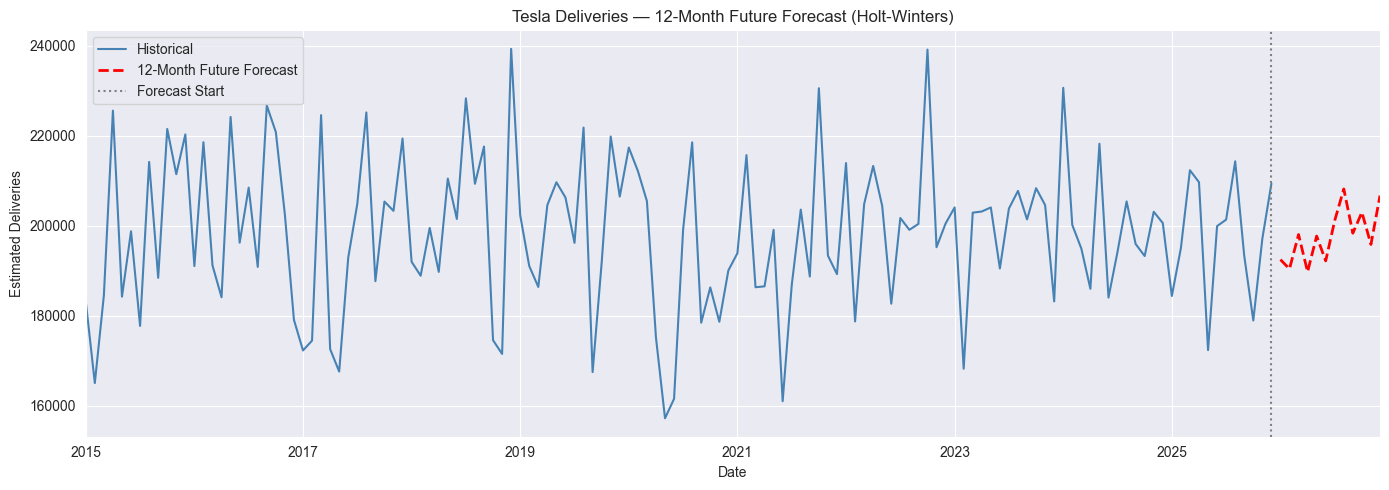


=== Predicted Deliveries (next 12 months) ===
2026-01-01    192500
2026-02-01    190433
2026-03-01    198068
2026-04-01    189790
2026-05-01    197734
2026-06-01    192219
2026-07-01    201204
2026-08-01    208203
2026-09-01    198373
2026-10-01    203014
2026-11-01    195868
2026-12-01    206738
Freq: MS, Name: Forecast, dtype: int64


In [22]:
final_hw    = ExponentialSmoothing(ts, trend='add', seasonal='add',
                                    seasonal_periods=12).fit()
future      = final_hw.forecast(12)
future.index = pd.date_range(
    start=ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')

plt.figure(figsize=(14, 5))
ts.plot(label='Historical', color='steelblue', linewidth=1.5)
future.plot(label='12-Month Future Forecast', color='red', linestyle='--', linewidth=2)
plt.axvline(ts.index[-1], color='gray', linestyle=':', linewidth=1.5,
            label='Forecast Start')
plt.title('Tesla Deliveries — 12-Month Future Forecast (Holt-Winters)')
plt.xlabel('Date'); plt.ylabel('Estimated Deliveries')
plt.legend(); plt.tight_layout(); plt.show()

print("\n=== Predicted Deliveries (next 12 months) ===")
print(future.round(0).astype(int).rename('Forecast'))

---
## 7. Summary

| Stage | Key Findings |
|---|---|
| **Preprocessing** | 2641 records, no missing values; encoded 3 categorical columns |
| **EDA** | Deliveries trend upward YoY; North America & Europe lead; strong CO₂ correlation |
| **Feature Eng.** | Added Delivery_Rate, CO2_per_Delivery, Price_per_Range, Quarter, Season |
| **Regression** | Random Forest & Gradient Boosting achieve R² > 0.98 |
| **Tuning** | GridSearchCV improved depth/estimator balance; Year & CO2_Saved_tons are top features |
| **Forecasting** | Holt-Winters captures seasonality well; ARIMA tracks trend; both used for 12-month future forecast |